In [1]:
from strategy import *


In [2]:
P = load_params('local_params_strategy.par')

#The output hdf5 file containing the generated TODs. 
tod_file=P['path']+'TOD_'+P['file'][:-5]+'.hdf5' #os.getcwd()+'/'+
#Load the names of the detectors. We assigned to them random names so that we cannot do naive for loop and avoid mistakes.
det_names_dict = pd.read_csv(P['detectors_name_file'], sep='\t')
det_names = det_names_dict['Name']

Text(0.5, 0, '$\\rm t_{int}$ [s]')

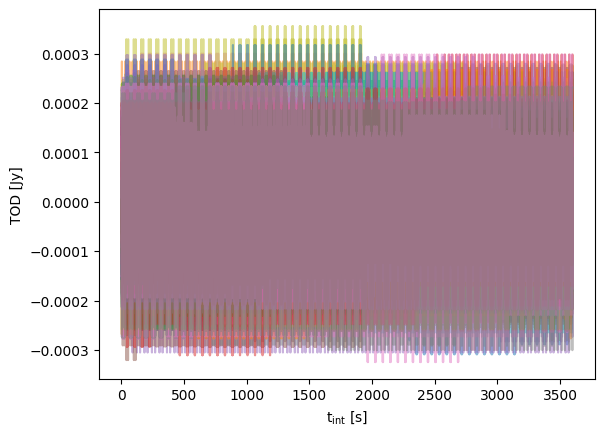

In [3]:

det_names_dict = pd.read_csv(P['detectors_name_file'], sep='\t')
#Each pixel with the same offset sees the same beam, but in different frequency band. 
same_offset_groups = det_names_dict.groupby(['Frequency'])['Name'].apply(list).reset_index()

#For each group of pixels seeing the same beam: 
datas = []

for group in range(len(same_offset_groups)): #len(same_offset_groups)
    H = h5py.File(tod_file, "a")    
    f =  H['time']
    time = f['data'][()]

    for j, name in  enumerate(same_offset_groups.iloc[group]['Name']):
        if(j>0): continue
        namegrp = f'kid_{name}_roach'
        f = H[namegrp]
        data = f['data'][()]
        datas.append(data)
        plt.plot(time, data, alpha=0.5)
    H.close()
plt.ylabel('TOD [Jy]')
plt.xlabel('$\\rm t_{int}$ [s]')

In [4]:
# 1. Compute time differences
dtime = np.diff(time)

# 2. Define a tolerance for considering time steps "equal"
tol = 1e-6  # adjust depending on your data's precision

# 3. Identify where the time difference changes
change_points = np.where(np.abs(np.diff(dtime)) > tol)[0] + 1

# 4. Add start and end indices
segment_edges = np.concatenate(([0], change_points, [len(time)-1]))

# 5. Split into individual constant-speed scan segments
segment_list = []
for data in datas:
    for i in range(len(segment_edges) - 1):
        start = segment_edges[i]
        end = segment_edges[i+1]
        segment_list.append(data[start:end+1])  # +1 to include the endpoint

time_segments = [time[start:end+1] for start, end in zip(segment_edges[:-1], segment_edges[1:])]
# segments is now a list of arrays with each constant-speed scan

time_segments = time_segments * len(datas)



Text(0, 0.5, '$\\rm S_{\\nu}$ [Jy]')

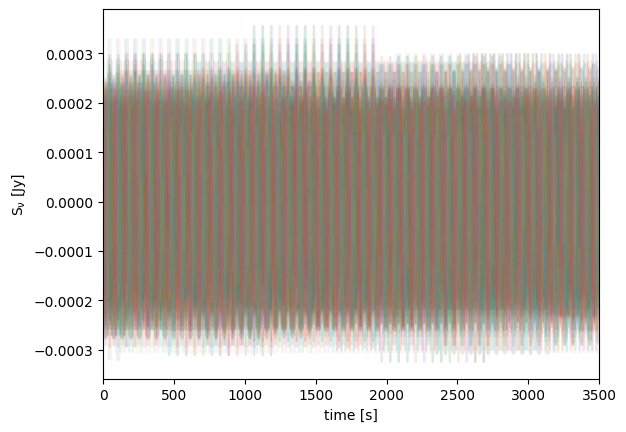

In [5]:
for i, (t, s) in enumerate(zip(segment_list, time_segments)): plt.plot(s,t, alpha=0.1)
plt.xlim(0, 3500)
plt.xlabel('time [s]')
plt.ylabel('$\\rm S_{\\nu}$ [Jy]')

/home/mvancuyck/anaconda3/envs/camb/lib/python3.9/site-packages/matplotlib/scale.py:255: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


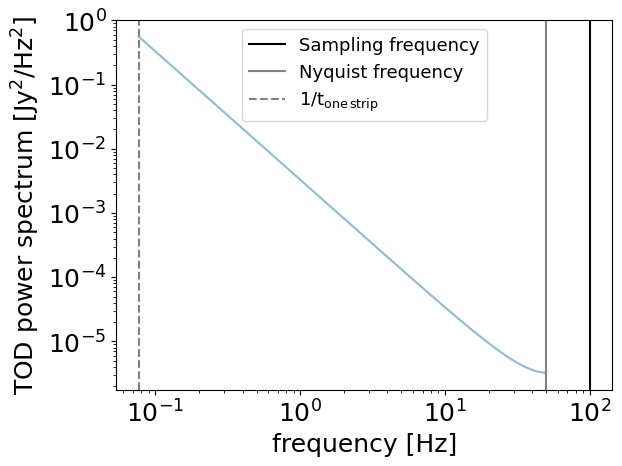

In [10]:
BS=18; plt.rc('font', size=BS); plt.rc('axes', titlesize=BS); plt.rc('axes', labelsize=BS); 

dt = P['dt']*np.pi/3.14 #Make the timestep non rational to avoid some stripes in the hitmap. 
sample_freq = 1 / np.round(dt*3600,3)
ffts_list = []
for i, (t, s) in enumerate(zip(segment_list, time_segments)):
        if(i!=0): continue
        freq_fft = np.fft.fftfreq(len(t), 1/sample_freq) #TOD frequencies.
        inds = np.where(freq_fft>0) 
        fft =  ( np.fft.fft(s) * (1/sample_freq) * np.conj( np.fft.fft(s) * (1/sample_freq) ) / len(s)  ).real
        if(len(fft[inds])!=0): 
                ffts_list.append(fft[inds])
                plt.loglog(freq_fft[inds], fft[inds], alpha=0.5)
'''
freq_fft = np.fft.fftfreq(len(time), 1/sample_freq) #TOD frequencies.
inds = np.where(freq_fft>0) 
fft =  ( np.fft.fft(data) * (1/sample_freq) * np.conj( np.fft.fft(data) * (1/sample_freq) ) / len(data)  ).real
plt.loglog(freq_fft[inds], fft[inds], 'k')
'''

plt.axvline(sample_freq, ymin=1e-20, ymax=1e10, color='k', label='Sampling frequency')
plt.axvline(sample_freq/2, ymin=1e-20, ymax=1e10, color='grey', label='Nyquist frequency')
plt.axvline(1/(np.round(dt*3600,3)*len(t)),  ymin=1e-20, ymax=1e10, color='grey', ls='--', label='$\\rm 1/t_{one\,strip}$')
#plt.axvline(fmax, ymin=1e-20, ymax=1e10, color='gray', label='$\\rm 1/t_{int}$')
plt.xlabel('frequency [Hz]')
plt.ylabel('TOD power spectrum [$\\rm Jy^2/Hz^2$]')
plt.legend(fontsize=13)

In [7]:
ffts = np.asarray(ffts_list)
fft_mean =np.mean(ffts, axis=0)
fft_std =np.std(ffts, axis=0)
f = freq_fft[inds]

import pickle

d = {'tdo_fft_mean [jy2/hz2]': fft_mean,
     'tdo_fft_std [jy2/hz2]': fft_std,
     'ft_freq [hz]': f}
pickle.dump(d, open('fits_and_hdf5/tod_fft.p', 'wb'))
plt.errorbar(fft_mean, yerr=fft_std)

TypeError: errorbar() missing 1 required positional argument: 'y'